In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import evalml
from evalml import AutoMLSearch
from evalml.utils import infer_feature_types

In [4]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/odroid1_firefox_carbonyl7.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/odroid2_firefox_carbonyl7.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/odroid3_firefox_carbonyl7.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/odroid4_firefox_carbonyl7.csv")

In [5]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/rpi-4a_chrome_carbonyl7.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/rpi-8a_chrome_carbonyl7.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/rpi_8b_carbonyl_onscreen.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/rpi_8c_carbonyl_onscreen.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/rpi-8d_chrome_carbonyl7.csv")

In [6]:
df = pd.concat([odroid1[:1000], odroid2[:1000], odroid3[:1000], odroid4[:1000], rpi4a[:1000], rpi8a[:1000], rpi8b[:1000], rpi8c[:1000], rpi8d[:1000]])
df = df.sample(frac=1).reset_index(drop=True)

In [7]:
df.head()

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
0,rpi_8c,62.8,63.6,61.1,60.2,60.5,60.7,60.2
1,odroid3,84.2,82.4,81.7,80.7,80.2,80.4,80.2
2,odroid1,87.9,85.9,85.4,84.0,83.8,83.5,83.8
3,rpi-4a,63.1,60.5,60.3,59.3,60.6,95.2,59.2
4,odroid2,87.2,86.1,85.0,84.2,83.6,84.0,83.7


In [39]:
X = df.iloc[:, 1:]
y = df.iloc[:, :1].squeeze()

In [40]:
X = infer_feature_types(
    X,
)

In [41]:
X.ww

,Physical Type,Logical Type,Semantic Tag(s)
Column,,,
Feature 0,float64,Double,['numeric']
Feature 1,float64,Double,['numeric']
Feature 2,float64,Double,['numeric']
Feature 3,float64,Double,['numeric']
Feature 4,float64,Double,['numeric']
Feature 5,float64,Double,['numeric']
Feature 6,float64,Double,['numeric']


In [42]:
X_train, X_holdout, y_train, y_holdout = evalml.preprocessing.split_data(
    X, y, problem_type="multiclass", test_size=0.2
)

/home/zac/miniconda3/envs/evalml/lib/python3.11/site-packages/woodwork/type_sys/utils.py:33: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [43]:
evalml.objectives.get_all_objective_names()

['expvariance',
 'maxerror',
 'medianae',
 'mse',
 'mae',
 'r2',
 'mean squared log error',
 'root mean squared log error',
 'root mean squared error',
 'symmetric mean absolute percentage error',
 'mean absolute percentage error',
 'mean absolute scaled error',
 'mcc multiclass',
 'log loss multiclass',
 'auc weighted',
 'auc macro',
 'auc micro',
 'recall weighted',
 'recall macro',
 'recall micro',
 'precision weighted',
 'precision macro',
 'precision micro',
 'f1 weighted',
 'f1 macro',
 'f1 micro',
 'balanced accuracy multiclass',
 'accuracy multiclass',
 'mcc binary',
 'log loss binary',
 'gini',
 'auc',
 'recall',
 'precision',
 'f1',
 'balanced accuracy binary',
 'accuracy binary',
 'sensitivity at low alert rates',
 'lead scoring',
 'fraud cost',
 'cost benefit matrix']

In [46]:
automl = AutoMLSearch(
    X_train=X_train,
    y_train=y_train,
    problem_type="multiclass",
    objective="f1 macro",
    max_batches=10,
    verbose=True,
)

AutoMLSearch will use mean CV score to rank pipelines.



*****************************
* Beginning pipeline search *
*****************************

Optimizing for F1 Macro. 
Greater score is better.

Using SequentialEngine to train and score pipelines.
Searching up to 10 batches for a total of None pipelines. 
Allowed model families: 

Evaluating Baseline Pipeline: Mode Baseline Multiclass Classification Pipeline
Mode Baseline Multiclass Classification Pipeline:
	Starting cross validation
	Finished cross validation - mean F1 Macro: 0.022

*****************************
* Evaluating Batch Number 1 *
*****************************

Random Forest Classifier w/ Label Encoder + Imputer + RF Classifier Select From Model:
	Starting cross validation
	Finished cross validation - mean F1 Macro: 0.654

*****************************
* Evaluating Batch Number 2 *
*****************************

LightGBM Classifier w/ Label Encoder + Imputer + Select Columns Transformer:
	Starting cross validation
	Finished cross validation - mean F1 Macro: 0.653
Extra Tree

/home/zac/miniconda3/envs/evalml/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2981: UserWarning:

The y_pred values do not sum to one. Starting from 1.5 thiswill result in an error.

/home/zac/miniconda3/envs/evalml/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2981: UserWarning:

The y_pred values do not sum to one. Starting from 1.5 thiswill result in an error.



XGBoost Classifier w/ Label Encoder + Imputer + Select Columns Transformer:
	Starting cross validation
	Finished cross validation - mean F1 Macro: 0.665


/home/zac/miniconda3/envs/evalml/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2981: UserWarning:

The y_pred values do not sum to one. Starting from 1.5 thiswill result in an error.

/home/zac/miniconda3/envs/evalml/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/zac/miniconda3/envs/evalml/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the dat

Logistic Regression Classifier w/ Label Encoder + Imputer + Standard Scaler + Select Columns Transformer:
	Starting cross validation
	Finished cross validation - mean F1 Macro: 0.535


...

XGBoost Classifier w/ Label Encoder + Imputer + Select Columns Transformer:
	Starting cross validation
	Finished cross validation - mean F1 Macro: 0.633


/home/zac/miniconda3/envs/evalml/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2981: UserWarning:

The y_pred values do not sum to one. Starting from 1.5 thiswill result in an error.



Random Forest Classifier w/ Label Encoder + Imputer + Select Columns Transformer:
	Starting cross validation
	Finished cross validation - mean F1 Macro: 0.666



Do you really want to exit search (y/n)?  y


Exiting AutoMLSearch.

Search finished after 185.26 seconds   
Best pipeline: LightGBM Classifier w/ Label Encoder + Imputer + Select Columns Transformer
Best pipeline F1 Macro: 0.676021


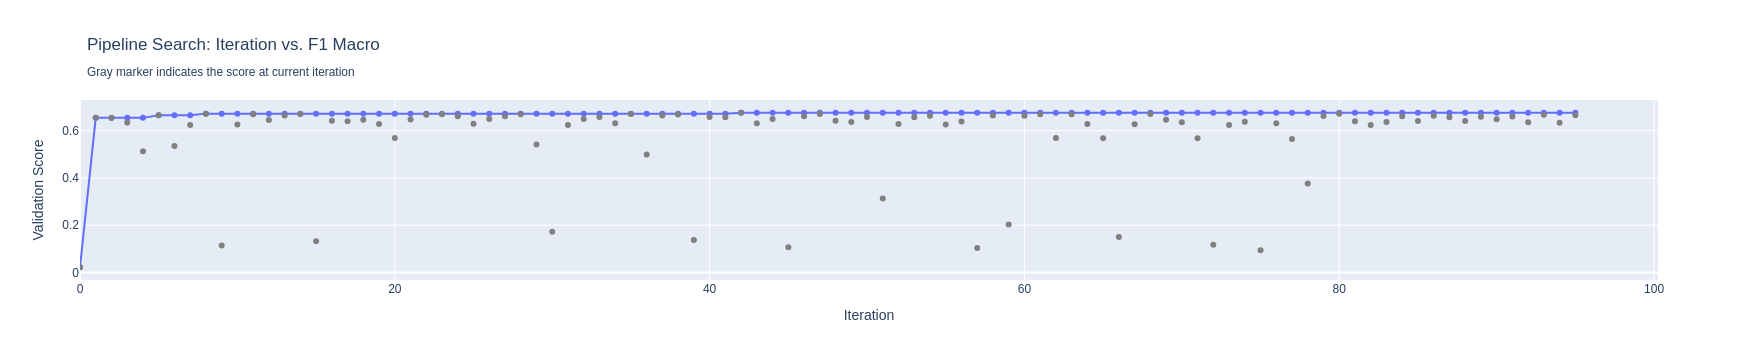

{1: {'Random Forest Classifier w/ Label Encoder + Imputer + RF Classifier Select From Model': 1.131117820739746,
  'Total time of batch': 1.2393217086791992},
 2: {'LightGBM Classifier w/ Label Encoder + Imputer + Select Columns Transformer': 1.2526485919952393,
  'Extra Trees Classifier w/ Label Encoder + Imputer + Select Columns Transformer': 0.5151276588439941,
  'Elastic Net Classifier w/ Label Encoder + Imputer + Standard Scaler + Select Columns Transformer': 0.6330809593200684,
  'XGBoost Classifier w/ Label Encoder + Imputer + Select Columns Transformer': 0.8611111640930176,
  'Logistic Regression Classifier w/ Label Encoder + Imputer + Standard Scaler + Select Columns Transformer': 0.8281166553497314,
  'Total time of batch': 4.624073028564453},
 3: {'XGBoost Classifier w/ Label Encoder + Imputer + Select Columns Transformer': 1.126997470855713,
  'Random Forest Classifier w/ Label Encoder + Imputer + Select Columns Transformer': 0.9018828868865967,
  'LightGBM Classifier w/ La

In [47]:
automl.search(interactive_plot=False)